In [1]:
!ls "../datos_cultivos/"

 CHLORELLA-20260126T182532Z-3-001
 Chlorella-20260126T182158Z-3-001
 Haematococcus_verde1-20260126T202441Z-3-001
 Haematococcus_verde2-20260126T213243Z-3-001
'Scenedesmus acutus_ 1_50-20260126T214011Z-3-001'
'Scenedesmus acutus_1_100-20260126T214147Z-3-001'


# Image reading

In [2]:
from pathlib import Path
import numpy as np
np.random.seed(42)

In [3]:
IMG_SUFFIXES = ["amp", "flr_1", "flr_2", "flr_3", "flu", "mask", "phase"] # 7 Channels per image or microalgae
class_names = ["Chlorella", "Haematococcus"] # Names of each class


"""
@brief Groups images for each corresponding microalgae.
      Each microalgae is given by 7 different images.
      Images format for a single microalgae:
        - Common_id + Different_suffix
        - Possible suffixes: ["amp", "flr_1", "flr_2", "flr_3", "flu", "mask", "phase"]
This function takes a list of image paths (potentially unordered) and groups them
by a common base identifier inferred from the filename. Each image is expected
to end with "_<suffix>" where <suffix> belongs to @p img_sufix.

A group is considered valid only if it contains ALL required suffixes.
The returned samples preserve the channel order defined by @p img_sufix.

@param paths List of filesystem paths (Path objects) pointing to .png images.
@param img_sufix List of required image suffixes (e.g., ["amp","flr_1",...]).
@return List of samples. Each sample is a list of Path objects ordered as @p img_sufix.
        Only complete samples (all suffixes present) are returned.
"""
def group_imgs(paths, img_sufix):
    # key -> common base image id (without "_<suffix>")
    # value -> dict mapping suffix -> Path
    groups = {} # { base_id_1: \{ "amp": Path(...), "flr_1": Path(...), ... \},   base_id_2: {...} }
    for path in paths:
        stem = path.stem  # name without .png
        t = next((t for t in img_sufix if stem.endswith("_" + t)), None) # Detect which suffix this file corresponds to
        if t is None: # Skip if suffix doesn't match
            continue
            
        base = stem[:-(len(t) + 1)]  # Remove "_<suffix>" from the end to get the common base id. Ej: Chlroella_001_123_23_amp -> Chlroella_001_123_23

        groups.setdefault(base, {})[t] = path # add image to dictionary (or create it if it doesn't already)

    # Keep only complete samples (those containing all required suffixes)
    result = []
    for d in groups.values():
        if all(t in d for t in img_sufix):
            result.append([d[t] for t in img_sufix])

    return result


"""
@brief Scan a dataset directory and build (X_paths, y) for multi-channel classification.

The dataset is assumed to be organized in class folders under @p base_dir.
Each top-level folder is matched against a prefix->label mapping (e.g., "CH"->0).
Inside each matched folder, PNG files under "class*/*.png" are collected and grouped
into complete multi-channel samples using @ref group_imgs.

Each returned sample corresponds to one cell/microalga and contains one file path
per suffix (channel), ordered according to @p img_suffixes.

@param base_dir Root directory (Path) containing class folders.
@param img_suffixes List of required image suffixes defining the channel order.
@return Tuple (X_paths, y):
        - X_paths: numpy array of shape (N, C) with dtype=object, where C=len(img_suffixes),
                  each entry is a string path to the corresponding channel image.
        - y: numpy array of shape (N,) with dtype=int32 containing integer class labels.
"""
def load_dataset(base_dir: Path, img_suffixes):
    # Prefix-to-label mapping for the species/classes included in this dataset.
    class_prefix = {"CH" : 0, # Chlorella
                    "HA" : 1 # Haematococcus
                   }
    X_paths = []
    y = []

    # Iterate over top-level entries in base_dir (expected: class folders)
    for class_dir in base_dir.iterdir():
        if not class_dir.is_dir():
            continue
        # Only read imgs in folders with prefix of microalgae that we want (Chlorella -> CH, Haematococcus -> HA, ...)
        for prefix, label in class_prefix.items():
            if class_dir.name.upper().startswith(prefix):
                # Collect all PNGs under subfolders matching "class*"
                paths = [p for p in class_dir.rglob("class*/*.png")]
                
                # Group into complete multi-channel samples: list of lists of Paths
                groups = group_imgs(paths, img_suffixes)  # list of [paths] in img_sufix order

                for img_channel_path in groups:
                    # Safety check: ensure correct number of channels
                    if len(img_channel_path) != len(img_suffixes):
                        continue
                    # Store file paths as strings (tf.data works better with strings)
                    X_paths.append([str(p) for p in img_channel_path])
                    y.append(label)

    # Convert to numpy arrays
    X_paths = np.asarray(X_paths, dtype=object)  # (N,C)
    y = np.asarray(y, dtype=np.int32)            # (N,)
    return X_paths, y


In [4]:
BASE_DIR = Path("..") / "datos_cultivos"

# Build the dataset as:
#   - X_paths: array of shape (N, 7) with file paths (strings) for each channel in IMG_SUFFIXES order
#   - y:       array of shape (N,) with integer labels (0=CH, 1=HA)
X_paths, y = load_dataset(BASE_DIR, IMG_SUFFIXES)
print(X_paths.shape, y.shape)  # (N,7) y (N,)

(3743, 7) (3743,)


# Preprocess

In [10]:
rng = np.random.default_rng(42)

# Get indices for each class
idx0 = np.where(y == 0)[0] # Indices of samples belonging to class 0 (Chlorella)
idx1 = np.where(y == 1)[0] # Indices of samples belonging to class 1 (Haematococcus)

# Determine the number of samples to keep per class (minimum class size)
n = min(len(idx0), len(idx1))

# Randomly permute and select n samples from each class
idx0 = rng.permutation(idx0)[:n]
idx1 = rng.permutation(idx1)[:n]

# Merge class indices and shuffle to mix classes
idx = np.concatenate([idx0, idx1])
idx = rng.permutation(idx)

# Reindex dataset to obtain a balanced and shuffled version
X_paths = X_paths[idx]
y = y[idx]

print("Chlorella instances: ", len(idx0))
print("Haematoccus instances: ", len(idx1))

Chlorella instances:  1727
Haematoccus instances:  1727


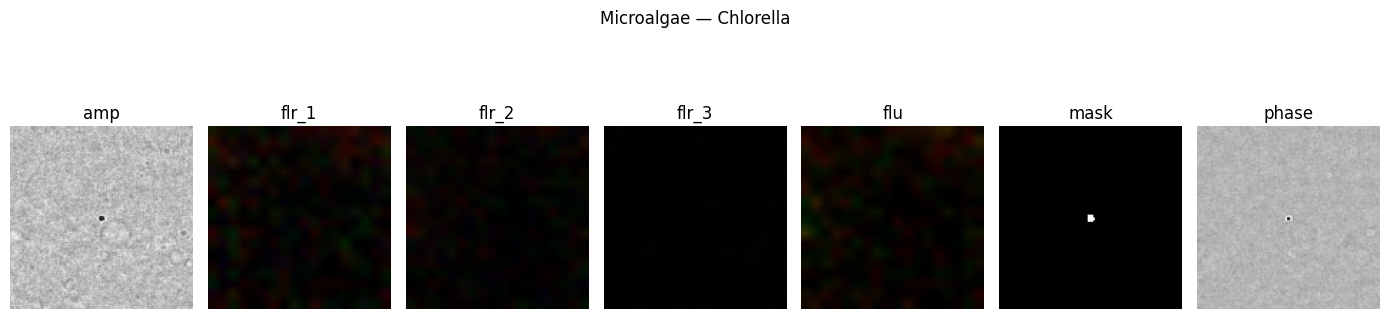

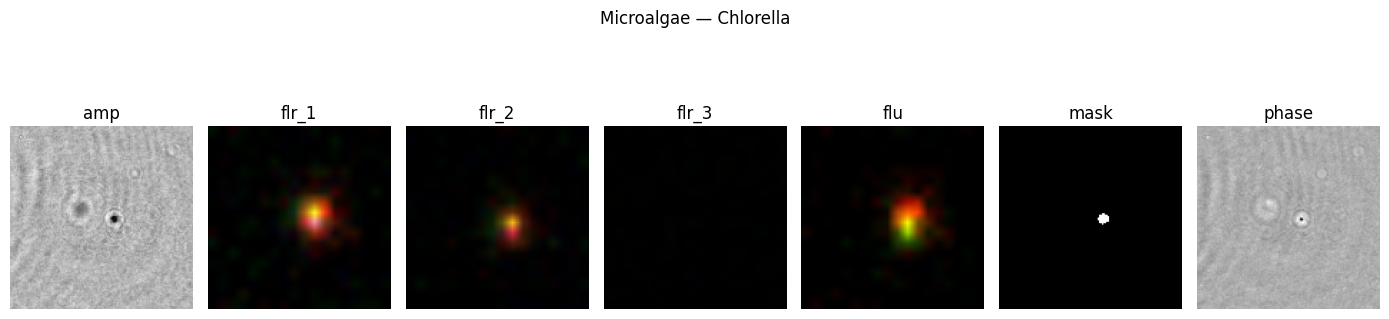

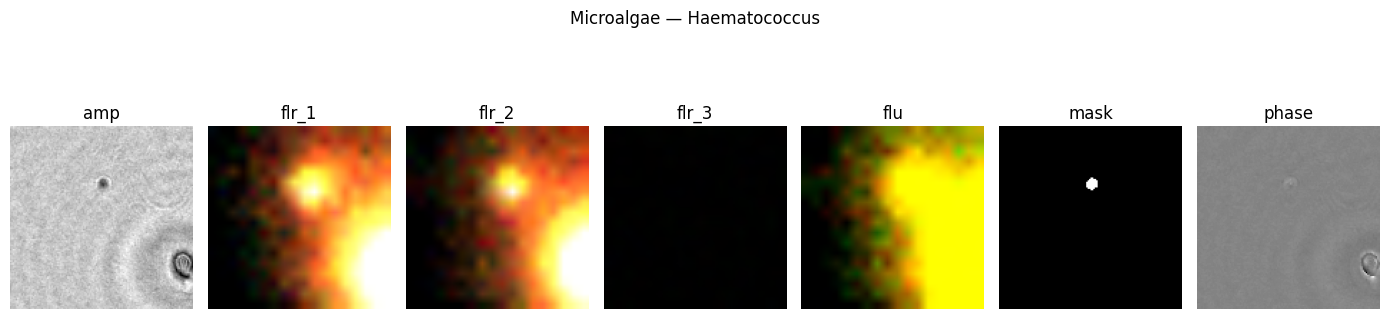

In [6]:
import matplotlib.pyplot as plt
from PIL import Image


"""
@brief: Displays all image channels of a single microalga sample
        Visualizes the multi-channel images corresponding to one microalga
        in a single row. Each subplot represents one imaging modality
        (amp, flr_1, ..., phase) and preserves the channel order defined
        by @img_suffixes.

        Optionally, the class label is shown in the figure title.

@param paths
        List or array of image paths (strings or Path objects),
        one per channel.
@param img_suffixes
        List of channel suffix names used as subplot titles.
@param label
        Integer class label (optional).
@param class_names
        List of class name strings indexed by label (optional).
@return
        None. This function displays a matplotlib figure.
"""

def show_microalgae_imgs(paths, img_suffixes, label=None, class_names=None):

    plt.figure(figsize=(14, 4))

    for i, (p, t) in enumerate(zip(paths, img_suffixes)):
        img = Image.open(p)
        plt.subplot(1, 7, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(t)
        plt.axis("off")

    title = "Microalgae"
    if label is not None and class_names is not None:
        title += f" — {class_names[label]}"

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Show first Chlorella
idx = np.where(y == 0)[0][0] # np.where(y == 0) --> array where y == 0, ej: [0, 2, 5]
show_microalgae_imgs(X_paths[idx], img_suffixes=IMG_SUFFIXES, label=y[idx], class_names=class_names)

# Show second Chlorella
idx = np.where(y == 0)[0][1]
show_microalgae_imgs(X_paths[idx], img_suffixes=IMG_SUFFIXES, label=y[idx], class_names=class_names)

# Show first Haematococcus
idx = np.where(y == 1)[0][0] 
show_microalgae_imgs(X_paths[idx], img_suffixes=IMG_SUFFIXES, label=y[idx], class_names=class_names)

In [7]:
len(X_paths), len(y), y[:5], y[-5:]

(3454,
 3454,
 array([0, 0, 1, 1, 1], dtype=int32),
 array([1, 1, 0, 0, 1], dtype=int32))

# Analisis

In [8]:
import numpy as np
from PIL import Image


"""
@brief Loads an image channel and flattens it into a 1D float array
        Opens an image file, converts it to grayscale, casts it to
        float32, and flattens it into a 1D vector.

@param path
        Path (string or Path object) to the image file.
@return
        1D numpy array (float32) containing the flattened pixel values.
"""
def load_flat_channel(path):
    img = Image.open(path).convert("L")
    return np.asarray(img, dtype=np.float32).ravel()

# Limit the number of samples to avoid excessive memory usage
N = min(100, len(X_paths))
X_sub = X_paths[:N]

# Build a matrix of shape [num_samples, num_channels, num_pixels]
channels = []
for c in range(len(IMG_SUFFIXES)):
    # Load and flatten the c-th channel for all selected samples
    ch_imgs = [load_flat_channel(p[c]) for p in X_sub]
    channels.append(np.stack(ch_imgs))

# Reduce each channel image to a single scalar per sample (mean intensity)
# Resulting shape: (N, num_channels)
features = np.stack([ch.mean(axis=1) for ch in channels], axis=1)  # (N,7)

# Compute channel-to-channel correlation matrix
corr = np.corrcoef(features.T)
print(corr)


[[ 1.         -0.49892142 -0.53700473 -0.06060071 -0.45369197 -0.88496756
  -0.12641341]
 [-0.49892142  1.          0.98528301  0.15898531  0.9882518   0.53185808
  -0.07703184]
 [-0.53700473  0.98528301  1.          0.17901411  0.96962969  0.54490306
  -0.07440223]
 [-0.06060071  0.15898531  0.17901411  1.          0.15531225  0.05376832
  -0.06019802]
 [-0.45369197  0.9882518   0.96962969  0.15531225  1.          0.4836119
  -0.07990924]
 [-0.88496756  0.53185808  0.54490306  0.05376832  0.4836119   1.
   0.06508095]
 [-0.12641341 -0.07703184 -0.07440223 -0.06019802 -0.07990924  0.06508095
   1.        ]]


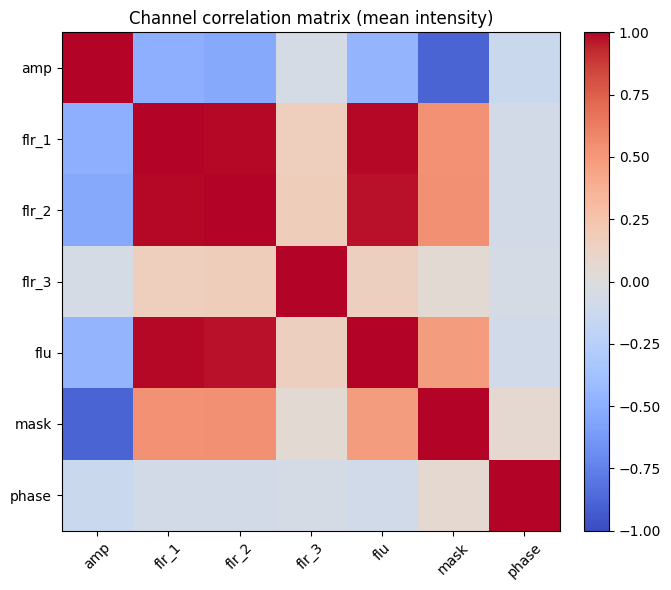

In [9]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(7, 6))

# Render correlation matrix as a heatmap
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Add colorbar with compact layout
plt.colorbar(im, fraction=0.046, pad=0.04)

# Label axes with channel names
plt.xticks(range(len(IMG_SUFFIXES)), IMG_SUFFIXES, rotation=45)
plt.yticks(range(len(IMG_SUFFIXES)), IMG_SUFFIXES)

plt.title("Channel correlation matrix (mean intensity)")
plt.tight_layout()
plt.show()

Las imágenes utilizadas en este trabajo constan inicialmente de siete canales (amp, flr_1, flr_2, flr_3, flu, mask y phase). Con el fin de reducir la dimensionalidad y evitar redundancias informativas, se realizó un análisis exploratorio previo al entrenamiento del modelo basado en la correlación entre canales y en la naturaleza de la información aportada por cada uno. Este análisis mostró una alta redundancia entre los canales de fluorescencia (flr_1, flr_2 y flu), así como la naturaleza no informativa del canal mask, mientras que phase aportó información morfológica complementaria y no correlacionada. El canal amp presentó información estructural adicional, y el canal flr_3, aunque poco correlacionado con el resto, no mostró evidencia clara de una contribución relevante adicional. En base a estos criterios, se decidió reformular el problema utilizando un subconjunto reducido de canales (amp, flr_1, flr_2 y phase).

Aunque flr_1 y flr_2 presentan alta correlación, se mantienen por precaución metodológica, mientras que flu, al representar una medida global altamente redundante con ambos, se excluye por no aportar información adicional.

# Train/Test Split

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

# Ensure clean and explicit dtypes
X_paths = np.asarray(X_paths, dtype=object)  # (N,7)
y = np.asarray(y, dtype=np.int32)             # (N,)

# First split: training vs temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_paths, y,
    test_size=0.30,         # 30% reserved for validation + test
    random_state=42,        # Reproducibility
    stratify=y              # Preserve class distribution
)

# Second split: validation vs test (equal sizes)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,        # Split 30% into 15% val + 15% test
    random_state=42,
    stratify=y_temp
)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Shapes:
Train: (2417, 7) (2417,)
Val:   (518, 7) (518,)
Test:  (519, 7) (519,)


 Quedarnos solo con los 4 canales que dijimos anteriormente (amp, flr_1, flr_2 y phase)

In [11]:
import numpy as np


"""
@brief Selects a subset of image channels from a multi-channel dataset
        Reduces the number of channels by selecting only those specified
        in @idxs, while preserving sample order and alignment with labels.

@param X
        Numpy array of shape (N, C) with dtype=object, where each row
        contains C image paths corresponding to different channels.
@param idxs
        List of integer indices indicating which channels to keep.
@return
        Numpy array of shape (N, len(idxs)) with dtype=object containing
        only the selected channels.
"""
def select_channels(X, idxs):
    X = np.asarray(X, dtype=object)
    return X[:, idxs]

# Original channel order in X_paths (7 channels)
KEEP = ["amp", "flr_1", "flr_2", "phase"]

# Map channel names to their indices in IMG_SUFFIXES
keep_idx = [IMG_SUFFIXES.index(k) for k in KEEP]
print("Keeping indices:", keep_idx, "->", KEEP)

# Apply channel selection to each dataset split
X_train4 = select_channels(X_train, keep_idx)
X_val4   = select_channels(X_val,   keep_idx)
X_test4  = select_channels(X_test,  keep_idx)

print("Train:", X_train4.shape, y_train.shape)
print("Val:  ", X_val4.shape,   y_val.shape)
print("Test: ", X_test4.shape,  y_test.shape)

Keeping indices: [0, 1, 2, 6] -> ['amp', 'flr_1', 'flr_2', 'phase']
Train: (2417, 4) (2417,)
Val:   (518, 4) (518,)
Test:  (519, 4) (519,)


In [12]:
print("Class counts:")
print("Train:", np.bincount(y_train, minlength=2))
print("Val:  ", np.bincount(y_val, minlength=2))
print("Test: ", np.bincount(y_test, minlength=2))

Class counts:
Train: [1208 1209]
Val:   [259 259]
Test:  [260 259]


# TF

## Configuration

In [13]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# ------------------------
# -------- CONFIG --------
# ------------------------
IMG_SIZE = 128
BATCH = 32
class_names = ["Chlorella", "Haematococcus"]
NUM_CLASSES = len(class_names)
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, len(KEEP))  # (128,128,4)

## Read images and make the dataset

In [14]:
# -------------------------------------------------------------
# -------- TF.DATA: read 4 channels (already selected) --------
# -------------------------------------------------------------
"""
@brief Reads a single PNG image and converts it to a normalized float tensor
        Loads a PNG from disk, decodes it as grayscale (1 channel), resizes it
        to (IMG_SIZE, IMG_SIZE), and normalizes pixel values to [0, 1].

@param path
        Tensor (tf.string) containing the image file path.
@return
        Tensor of shape (IMG_SIZE, IMG_SIZE, 1) with dtype tf.float32.
"""
def _read_one_png(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_png(img_bytes, channels=1)  # (H,W,1)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    return img

"""
@brief Loads and stacks 4 image channels into a single multi-channel tensor
        Given a vector of 4 paths (in the order defined by KEEP), reads each PNG,
        and concatenates them along the channel axis to form an input tensor
        of shape (IMG_SIZE, IMG_SIZE, 4).

@param paths4
        Tensor of shape (4,) containing 4 file paths (tf.string).
@param label
        Integer label tensor corresponding to the sample.
@return
        Tuple (x, label):
        - x: Tensor of shape (IMG_SIZE, IMG_SIZE, 4) and dtype tf.float32.
        - label: Unchanged label tensor.
"""
def load_png_4ch(paths4, label):
    imgs = [
        _read_one_png(paths4[0]),
        _read_one_png(paths4[1]),
        _read_one_png(paths4[2]),
        _read_one_png(paths4[3]),
    ]
    x = tf.concat(imgs, axis=-1)  # (IMG_SIZE, IMG_SIZE, 4)
    return x, label


"""
@brief Builds a tf.data.Dataset pipeline for multi-channel image classification
        Creates a dataset from (X, Y) path/label arrays and optionally shuffles

@param X
        Numpy array of shape (N, 4) containing image paths (strings).
@param Y
        Numpy array of shape (N,) containing integer labels.
@param training
        Boolean indicating whether to enable shuffling for training.
@return
        tf.data.Dataset yielding batches of (x, y):
        - x: (BATCH, IMG_SIZE, IMG_SIZE, 4)
        - y: (BATCH,)
"""
def make_dataset(X, Y, training=False):
    X = np.asarray(X, dtype=str)      # (N,4)
    Y = np.asarray(Y, dtype=np.int32) # (N,)

    # Create a dataset of (paths, label) pairs
    ds = tf.data.Dataset.from_tensor_slices((X, Y))

    # Shuffle only during training to avoid order bias
    if training:
        ds = ds.shuffle(min(len(X), 2000), seed=42, reshuffle_each_iteration=True)

    # Load and stack the 4 image channels into a single tensor
    ds = ds.map(load_png_4ch, num_parallel_calls=tf.data.AUTOTUNE)

    # Group samples into batches and overlap preprocessing with training
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

# Build datasets
train_ds = make_dataset(X_train4, y_train, training=True)
val_ds   = make_dataset(X_val4,   y_val,   training=False)
test_ds  = make_dataset(X_test4,  y_test,  training=False)

# Enforce deterministic iteration for validation/test (reproducibility)
options = tf.data.Options()
options.experimental_deterministic = True
val_ds  = val_ds.with_options(options)
test_ds = test_ds.with_options(options)

## Build the model

In [15]:
# ------------------------
# -------- MODEL ---------
# ------------------------
"""
@brief Squeeze-and-Excitation block (adaptive channel weighting)
        Learns a per-channel importance weight for the current input and
        rescales feature maps accordingly.

        The block works in two steps:
        1) Squeeze: summarizes each channel by global average pooling,
           producing one scalar per channel (how "active" that channel is).
        2) Excitation: passes these scalars through a small MLP to generate
           gates in [0,1] (sigmoid), which are then used to reweight channels.

@param x
        Input tensor of shape (H, W, C), where C is the number of channels
        (feature maps).
@param ratio
        Reduction ratio for the bottleneck MLP. Larger values mean fewer
        parameters (stronger compression). Typical values: 8 or 16.
@return
        Tensor of shape (H, W, C) with channels scaled by learned gates.
"""
def se_block(x, ratio=8):
    # Number of channels (C) in the input feature map
    ch = x.shape[-1] 

    # If the channel dimension is unknown at build time, do nothing
    if ch is None:
        return x

    # SQUEEZE: (H, W, C) -> (C,)
    # For each channel, compute the spatial mean to summarize it
    s = layers.GlobalAveragePooling2D()(x)

    # EXCITATION: (C,) -> (C,)
    # Learn channel gates with a small bottleneck MLP:
    # - first Dense reduces dimensionality to (C/ratio) (at least 4)
    # - second Dense expands back to C and applies sigmoid -> gates in [0,1]
    s = layers.Dense(max(ch // ratio, 4), activation="relu")(s)
    s = layers.Dense(ch, activation="sigmoid")(s)

    # Reshape gates to broadcast over spatial dimensions: (C,) -> (1, 1, C)
    s = layers.Reshape((1, 1, ch))(s)

    # CHANNEL REWEIGHTING:
    # Multiply each channel of x by its corresponding gate value
    # x_out[..., c] = x[..., c] * s[..., c]
    return layers.Multiply()([x, s])

"""
@brief Convolutional feature extraction block with optional pooling and SE
        Applies two Conv2D + BatchNorm + ReLU layers, optionally followed by:
        - SE block (channel attention)
        - MaxPooling2D (spatial downsampling)
        - SpatialDropout2D (regularization)

@param x
        Input tensor.
@param filters
        Number of convolution filters.
@param l2
        L2 weight decay coefficient for convolution kernels.
@param sd
        SpatialDropout2D rate (0 disables).
@param pool
        If True, apply MaxPooling2D at the end of the block.
@param se
        If True, apply a Squeeze-and-Excitation block inside the block.
@return
        Output tensor after the block operations.
"""
def conv_block(x, filters, l2=1e-4, sd=0.10, pool=True, se=True):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if se:
        x = se_block(x, ratio=8)

    if pool:
        x = layers.MaxPooling2D()(x)
    if sd and sd > 0:
        x = layers.SpatialDropout2D(sd)(x)
    return x


"""
@brief Builds a deeper CNN model for 4-channel microalgae classification
        Constructs a multi-block CNN with increasing filter sizes and SE blocks,
        followed by a dense head and a softmax classifier.

@param l2
        L2 weight decay coefficient applied to Conv2D and Dense kernels.
@param drop_head
        Dropout rate applied in the dense classification head.
@param freeze_bn
        If True, sets all BatchNormalization layers to non-trainable.
@return
        A Keras Model with input shape (IMG_SIZE, IMG_SIZE, 4).
"""
def make_model(l2=1e-4, drop_head=0.25, freeze_bn=False):
    inp = keras.Input(shape=IMG_SHAPE)
    x = inp

    # Stem block: stabilizes early feature extraction
    x = layers.Conv2D(32, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Deeper convolutional blocks
    x = conv_block(x, 64,  l2=l2, sd=0.10, pool=True,  se=True)
    x = conv_block(x, 128, l2=l2, sd=0.15, pool=True,  se=True)
    x = conv_block(x, 256, l2=l2, sd=0.20, pool=True,  se=True)
    x = conv_block(x, 512, l2=l2, sd=0.20, pool=False, se=True)  # no pooling at the end

    x = layers.GlobalAveragePooling2D()(x)

    # Dense classification head
    x = layers.Dense(512, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(drop_head)(x)

    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(drop_head)(x)

    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inp, out, name="bigger_selected_channels_4ch_se_512")

    if freeze_bn:
        for layer in model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    return model

# Instantiate model
model = make_model(l2=1e-4, drop_head=0.25, freeze_bn=False)
print(model.name, model.input_shape)

bigger_selected_channels_4ch_se_512 (None, 128, 128, 4)


## Warmup LR

In [16]:
# ----------------------------
# -------- WARMUP LR ---------
# ----------------------------
"""
@brief Learning-rate warmup callback
        Linearly increases the learning rate from @start_lr to @target_lr
        during the first @warmup_epochs epochs. This can stabilize early
        training, especially for deeper models.

@param start_lr
        Initial learning rate at epoch 0.
@param target_lr
        Final learning rate reached at the end of warmup.
@param warmup_epochs
        Number of epochs over which to warm up.
@return
        None. Updates the optimizer learning rate at epoch start.
"""
class WarmupLR(keras.callbacks.Callback):
    def __init__(self, start_lr=1e-4, target_lr=1e-3, warmup_epochs=5):
        super().__init__()
        self.start_lr = start_lr
        self.target_lr = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.start_lr + (self.target_lr - self.start_lr) * (
                epoch / max(1, self.warmup_epochs - 1)
            )
            try:
                keras.backend.set_value(self.model.optimizer.learning_rate, lr)
            except Exception:
                keras.backend.set_value(self.model.optimizer.lr, lr)

## Train

In [17]:
# ----------------------------
# -------- TRAIN -------------
# ----------------------------
"""
@brief Compiles and trains the CNN model
        Trains using Adam optimizer and sparse categorical cross-entropy.
        Uses callbacks for learning-rate warmup, checkpointing, early stopping,
        and learning-rate reduction on plateau.

@return
        Training history object returned by model.fit().
"""
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    WarmupLR(start_lr=1e-4, target_lr=1e-3, warmup_epochs=5),
    keras.callbacks.ModelCheckpoint(
        "best_selected_channels_4ch.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=5e-4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=3e-6,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks,
    verbose=2
)

best_model_4ch = keras.models.load_model("best_selected_channels_4ch.keras")
print(best_model_4ch.name, best_model_4ch.input_shape)

Epoch 1/150
76/76 - 26s - loss: 0.7303 - accuracy: 0.7679 - val_loss: 1.0984 - val_accuracy: 0.5000 - lr: 1.0000e-04 - 26s/epoch - 347ms/step
Epoch 2/150
76/76 - 11s - loss: 0.6719 - accuracy: 0.8151 - val_loss: 1.4691 - val_accuracy: 0.5000 - lr: 3.2500e-04 - 11s/epoch - 140ms/step
Epoch 3/150
76/76 - 11s - loss: 0.6588 - accuracy: 0.8250 - val_loss: 1.8428 - val_accuracy: 0.3417 - lr: 5.5000e-04 - 11s/epoch - 140ms/step
Epoch 4/150
76/76 - 11s - loss: 0.6229 - accuracy: 0.8382 - val_loss: 0.9258 - val_accuracy: 0.5019 - lr: 7.7500e-04 - 11s/epoch - 147ms/step
Epoch 5/150
76/76 - 11s - loss: 0.5672 - accuracy: 0.8647 - val_loss: 0.8411 - val_accuracy: 0.5000 - lr: 0.0010 - 11s/epoch - 148ms/step
Epoch 6/150
76/76 - 11s - loss: 0.5498 - accuracy: 0.8693 - val_loss: 2.0784 - val_accuracy: 0.6120 - lr: 0.0010 - 11s/epoch - 140ms/step
Epoch 7/150
76/76 - 11s - loss: 0.5266 - accuracy: 0.8821 - val_loss: 0.5882 - val_accuracy: 0.8205 - lr: 0.0010 - 11s/epoch - 148ms/step
Epoch 8/150
76/76 

## Evaluation Helpers

In [18]:
# -----------------------------------
# -------- EVAL helpers -------------
# -----------------------------------
"""
@brief Collects predicted probabilities and true labels from a dataset
        Runs inference over all batches in @ds and concatenates:
        - y_prob: softmax probabilities
        - y_true: ground-truth labels

@param model
        Trained Keras model that outputs class probabilities.
@param ds
        tf.data.Dataset yielding (x, y) batches.
@return
        Tuple (y_prob, y_true):
        - y_prob: numpy array of shape (N, NUM_CLASSES)
        - y_true: numpy array of shape (N,)
"""
def get_probs_and_labels(model, ds):
    y_true, y_prob = [], []
    for x, yb in ds:
        p = model.predict(x, verbose=0)
        y_prob.append(p)
        y_true.append(yb.numpy())
    return np.concatenate(y_prob, axis=0), np.concatenate(y_true, axis=0)

"""
@brief Evaluates accuracy with a rejection threshold (tau)
        Converts probabilities to predictions, computes confidence as the
        max softmax probability, and rejects samples with confidence < tau.

@param y_true
        Numpy array of true labels of shape (N,).
@param y_prob
        Numpy array of predicted probabilities of shape (N, NUM_CLASSES).
@param tau
        Confidence threshold in [0, 1]. Samples with max prob < tau are rejected.
@return
        Dictionary with:
        - tau: used threshold
        - acc: accuracy on accepted samples (NaN if none accepted)
        - reject_rate: fraction of rejected samples
        - accepted: number of accepted samples
"""
def eval_with_tau(y_true, y_prob, tau):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)
    accepted = conf >= float(tau)
    reject_rate = 1.0 - accepted.mean()
    if accepted.sum() == 0:
        return dict(tau=float(tau), acc=np.nan, reject_rate=float(reject_rate), accepted=0)
    acc = float((y_pred[accepted] == y_true[accepted]).mean())
    return dict(tau=float(tau), acc=acc, reject_rate=float(reject_rate), accepted=int(accepted.sum()))

"""
@brief Computes a tau threshold that achieves a target rejection rate
        Uses the distribution of maximum softmax confidences and selects
        tau as the quantile corresponding to @target_reject.

        Example:
        - target_reject=0.14 -> tau = 14th percentile of confidence,
          so ~14% samples have confidence below tau and will be rejected.

@param y_prob
        Numpy array of predicted probabilities of shape (N, NUM_CLASSES).
@param target_reject
        Desired rejection fraction in [0, 1].
@return
        Tau threshold (float).
"""
def tau_for_target_reject(y_prob, target_reject=0.14):
    conf = np.max(y_prob, axis=1)
    return float(np.quantile(conf, target_reject))

"""
@brief Evaluates performance at a fixed target rejection rate
        Computes tau using @tau_for_target_reject and evaluates accuracy
        and reject rate using @eval_with_tau.

@param y_true
        Numpy array of true labels of shape (N,).
@param y_prob
        Numpy array of predicted probabilities of shape (N, NUM_CLASSES).
@param target_reject
        Desired rejection fraction in [0, 1].
@return
        Dictionary with tau, acc, reject_rate, accepted, and target_reject.
"""
def eval_at_reject(y_true, y_prob, target_reject=0.14):
    tau = tau_for_target_reject(y_prob, target_reject)
    r = eval_with_tau(y_true, y_prob, tau)
    r["target_reject"] = float(target_reject)
    return r

## PROBS + evaluation at 14% reject (VAL and TEST)

In [19]:
# ----------------------------------------------------------------------
# -------- PROBS + evaluation at 14% reject (VAL and TEST) -------------
# ----------------------------------------------------------------------
val_prob_4, val_true_4 = get_probs_and_labels(best_model_4ch, val_ds)
test_prob_4, test_true_4 = get_probs_and_labels(best_model_4ch, test_ds)

print("VAL@14%:", eval_at_reject(val_true_4, val_prob_4, 0.14))
print("TEST@14%:", eval_at_reject(test_true_4, test_prob_4, 0.14))

print("VAL acc no reject:", float((np.argmax(val_prob_4, axis=1) == val_true_4).mean()))
print("TEST acc no reject:", float((np.argmax(test_prob_4, axis=1) == test_true_4).mean()))


VAL@14%: {'tau': 0.8453770303726196, 'acc': 0.9775280898876404, 'reject_rate': 0.14092664092664098, 'accepted': 445, 'target_reject': 0.14}
TEST@14%: {'tau': 0.8925044798851014, 'acc': 0.9865470852017937, 'reject_rate': 0.140655105973025, 'accepted': 446, 'target_reject': 0.14}
VAL acc no reject: 0.9420849420849421
TEST acc no reject: 0.9421965317919075


## TAU Selection

In [20]:
import numpy as np

# ==========================================================
# 1) Utilidades: métricas por clase con rechazo
# ==========================================================
def per_class_metrics_with_tau(y_true, y_prob, tau, class_names):
    """
    Devuelve:
      - reject_rate global
      - acc global en aceptadas
      - por clase: acc(aceptadas), reject_rate_clase, accepted/total
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    y_pred = np.argmax(y_prob, axis=1)
    conf   = np.max(y_prob, axis=1)
    accpt  = conf >= float(tau)

    reject_rate = 1.0 - accpt.mean()

    # global acc solo aceptadas
    if accpt.sum() == 0:
        acc_global = np.nan
    else:
        acc_global = float((y_pred[accpt] == y_true[accpt]).mean())

    per_class = []
    for c, name in enumerate(class_names):
        m = (y_true == c)
        n_total = int(m.sum())
        if n_total == 0:
            per_class.append(dict(
                cls=name, acc=np.nan, reject=np.nan,
                accepted=0, total=0
            ))
            continue

        m_accpt = m & accpt
        n_accpt = int(m_accpt.sum())
        rej_c = 1.0 - (n_accpt / n_total)

        if n_accpt == 0:
            acc_c = np.nan
        else:
            acc_c = float((y_pred[m_accpt] == y_true[m_accpt]).mean())

        per_class.append(dict(
            cls=name, acc=acc_c, reject=float(rej_c),
            accepted=n_accpt, total=n_total
        ))

    return dict(
        tau=float(tau),
        acc_global=acc_global,
        reject_rate=float(reject_rate),
        accepted=int(accpt.sum()),
        total=int(len(y_true)),
        per_class=per_class
    )

def print_per_class_report(res):
    acc_txt = "nan" if not np.isfinite(res["acc_global"]) else f"{res['acc_global']:.4f}"
    print(f"tau={res['tau']:.3f} | acc(accepted)={acc_txt} | "
          f"reject={100*res['reject_rate']:.2f}% | accepted={res['accepted']}/{res['total']}")
    for pc in res["per_class"]:
        acc_c_txt = "nan" if not np.isfinite(pc["acc"]) else f"{pc['acc']:.4f}"
        print(f"  - {pc['cls']:<13} acc={acc_c_txt} | reject={100*pc['reject']:.2f}% | "
              f"accepted={pc['accepted']}/{pc['total']}")
    print()

# ==========================================================
# 2) Barrido de tau (VAL o TEST)
# ==========================================================
def sweep_taus(y_true, y_prob, class_names, taus, print_each=True, title=None):
    if title:
        print(title)
    rows = []
    for tau in taus:
        r = per_class_metrics_with_tau(y_true, y_prob, float(tau), class_names)
        rows.append(r)
        if print_each:
            print_per_class_report(r)
    return rows

# ==========================================================
# 3) Helper: mejor tau que logra target_acc (minimiza rechazo)
# ==========================================================
def best_tau_for_target_acc(rows, target_acc=0.99):
    feasible = [r for r in rows if np.isfinite(r["acc_global"]) and r["acc_global"] >= target_acc]
    if not feasible:
        best = max(rows, key=lambda r: (-1 if not np.isfinite(r["acc_global"]) else r["acc_global"]))
        return {"found": False, "best": best}
    best = min(feasible, key=lambda r: r["reject_rate"])  # menos rechazo = más cobertura
    return {"found": True, "best": best}

# ==========================================================
# Tau inicial = 12% de rechazo en VAL
# ==========================================================
conf_val = np.max(val_prob_4, axis=1)
tau_12 = float(np.quantile(conf_val, 0.12))

taus_sweep = np.unique(np.concatenate([
    np.linspace(tau_12, 0.90, 10),   # desde 12% reject hasta zona alta
    np.linspace(0.91, 0.95, 9),
    np.linspace(0.96, 0.99, 9),
    np.linspace(0.991, 0.999, 9),
]))

rows_val = sweep_taus(
    val_true_4, val_prob_4, class_names, taus_sweep,
    print_each=True,
    title="=== SWEEP en VAL (taus 0.70 -> 0.999) | 4ch ==="
)

# ¿Llegamos a 99% en VAL?
res99 = best_tau_for_target_acc(rows_val, target_acc=0.99)
if res99["found"]:
    print("✅ Se alcanza 0.99 en VAL. Mejor (menos rechazo) que cumple:")
else:
    print("❌ NO se alcanza 0.99 en VAL. Mejor encontrado:")
print_per_class_report(res99["best"])
'''
# (opcional) mismo sweep en TEST con los mismos taus
rows_test = sweep_taus(test_true_4, test_prob_4, class_names, taus_sweep,
                       print_each=False,
                       title="=== SWEEP en TEST (taus altos, resumen) | 4ch ===")
'''
# imprime solo el tau elegido en TEST (el de VAL)
tau_star = res99["best"]["tau"]
print("=== TEST usando el tau elegido en VAL | 4ch ===")
print_per_class_report(per_class_metrics_with_tau(test_true_4, test_prob_4, tau_star, class_names))

# ==========================================================
# 5) Tabla compacta (por si quieres copiar a Excel)
# ==========================================================
def compact_table(rows):
    out = []
    for r in rows:
        row = {
            "tau": r["tau"],
            "acc_global": r["acc_global"],
            "reject_rate": r["reject_rate"],
            "accepted": r["accepted"],
            "total": r["total"],
        }
        for pc in r["per_class"]:
            k = pc["cls"]
            row[f"{k}_acc"] = pc["acc"]
            row[f"{k}_reject"] = pc["reject"]
            row[f"{k}_accepted"] = pc["accepted"]
            row[f"{k}_total"] = pc["total"]
        out.append(row)
    return out

table_val = compact_table(rows_val)   # lista de dicts


=== SWEEP en VAL (taus 0.70 -> 0.999) | 4ch ===
tau=0.816 | acc(accepted)=0.9758 | reject=12.16% | accepted=455/518
  - Chlorella     acc=0.9957 | reject=10.81% | accepted=231/259
  - Haematococcus acc=0.9554 | reject=13.51% | accepted=224/259

tau=0.825 | acc(accepted)=0.9779 | reject=12.74% | accepted=452/518
  - Chlorella     acc=0.9956 | reject=11.58% | accepted=229/259
  - Haematococcus acc=0.9596 | reject=13.90% | accepted=223/259

tau=0.834 | acc(accepted)=0.9777 | reject=13.32% | accepted=449/518
  - Chlorella     acc=0.9956 | reject=11.97% | accepted=228/259
  - Haematococcus acc=0.9593 | reject=14.67% | accepted=221/259

tau=0.844 | acc(accepted)=0.9776 | reject=13.90% | accepted=446/518
  - Chlorella     acc=0.9956 | reject=13.13% | accepted=225/259
  - Haematococcus acc=0.9593 | reject=14.67% | accepted=221/259

tau=0.853 | acc(accepted)=0.9795 | reject=15.06% | accepted=440/518
  - Chlorella     acc=0.9955 | reject=13.51% | accepted=224/259
  - Haematococcus acc=0.9630 | r